In [7]:
# 1. IMPORT LIBRARIES AND LOAD DATA

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv("../data/top100_ai_tools_2026.csv")

print("Dataset Shape:", data.shape)
print("Columns:", data.columns)

Dataset Shape: (500, 13)
Columns: Index(['Rank', 'Tool_Name', 'Primary_Category', 'Sub_Category',
       'Pricing_Model', 'Starting_Price_USD', 'Monthly_Traffic_Est',
       'User_Rating', 'Agentic_Capability_Score', 'API_Available',
       'Release_Year', 'Active_Users_Est', 'Description'],
      dtype='str')


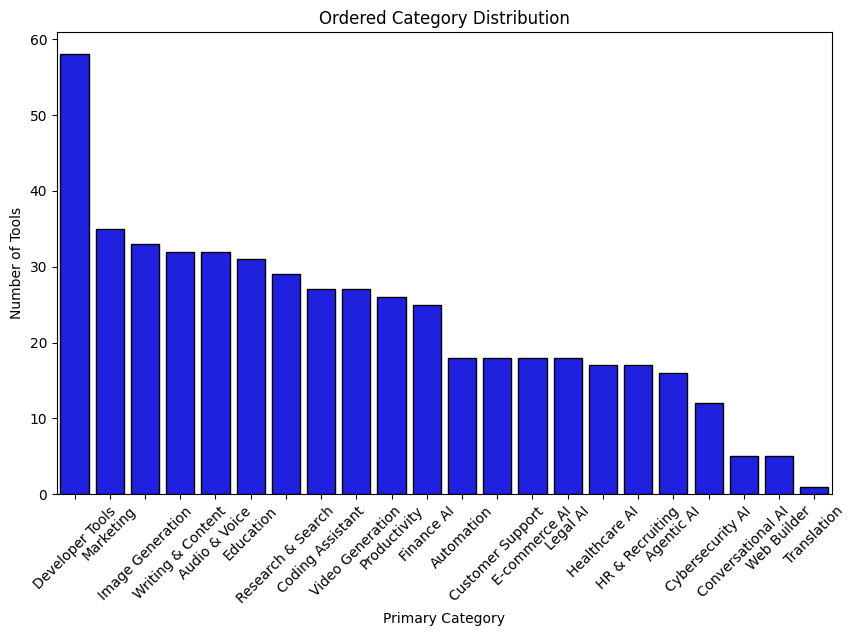

In [8]:
# 2. CATEGORY DISTRIBUTION WITH ORDERING

category_counts = data['Primary_Category'].value_counts()

plt.figure(figsize=(10,6))

sns.countplot(
    x='Primary_Category',
    data=data,
    order=category_counts.index,color='blue',edgecolor='black'
)

plt.xticks(rotation=45)
plt.xlabel("Primary Category")
plt.ylabel("Number of Tools")
plt.title("Ordered Category Distribution")

plt.show()

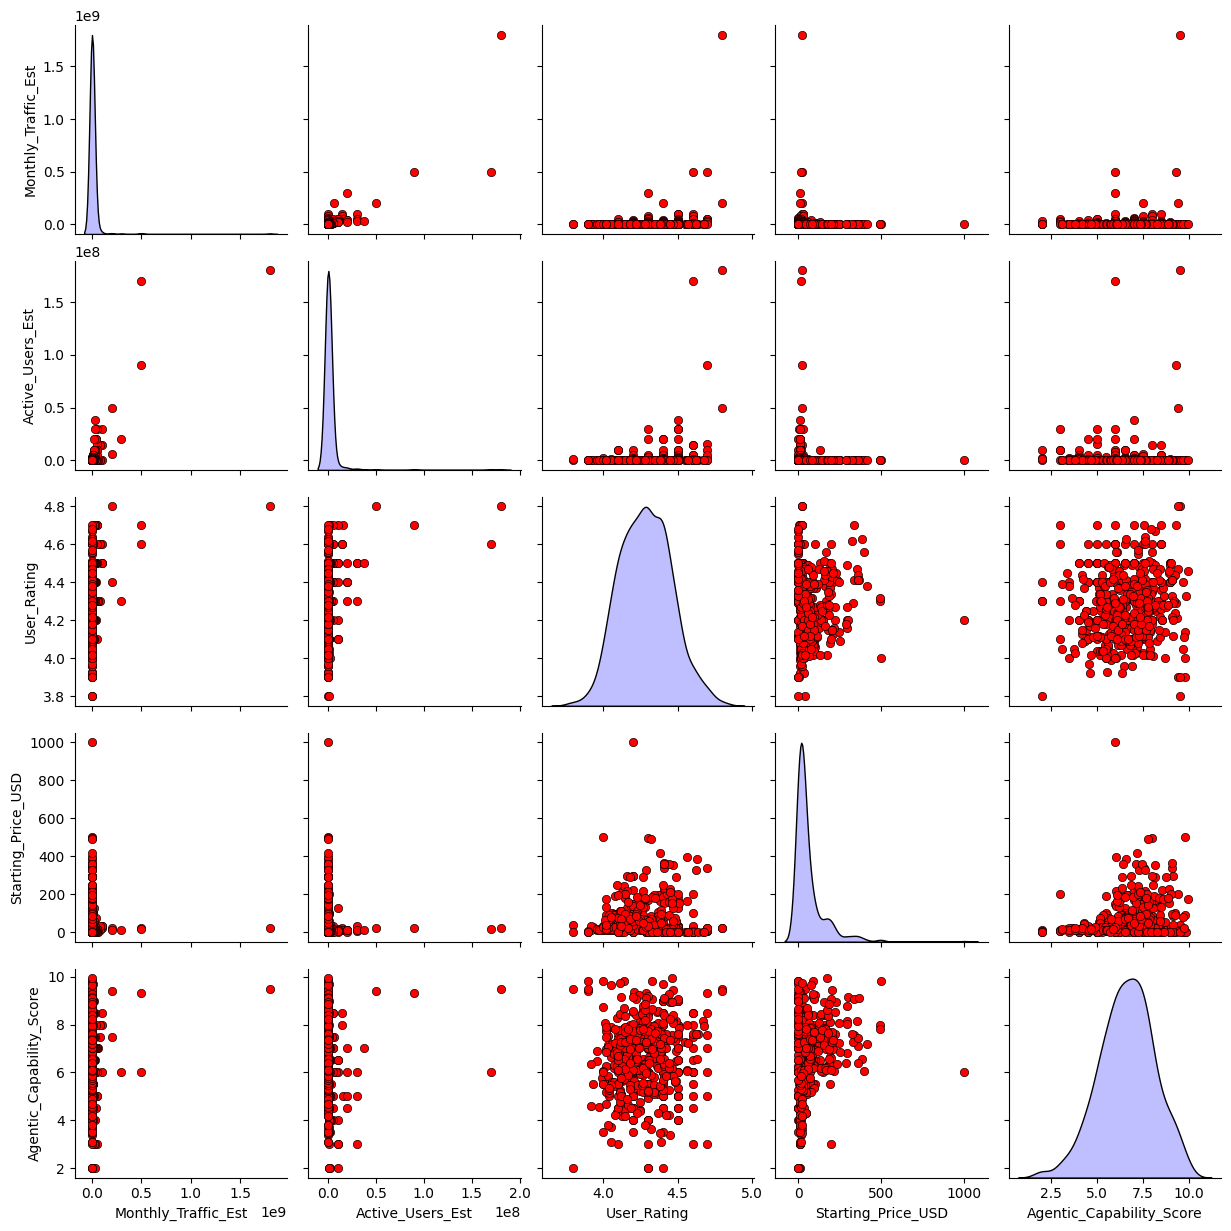

In [24]:
# 3. MULTI-VARIABLE PAIRPLOT (LARGE SCALE RELATIONSHIP ANALYSIS)

selected_features = [
    'Monthly_Traffic_Est',
    'Active_Users_Est',
    'User_Rating',
    'Starting_Price_USD',
    'Agentic_Capability_Score'
]

sns.pairplot(
    data[selected_features],
    diag_kind="kde",
    plot_kws={'color': 'red', 'edgecolor': 'black'},  # change scatter color and edge color here
    diag_kws={'color': 'blue', 'edgecolor': 'black'}  # color for the KDE (elliptic) curves
)

plt.show()

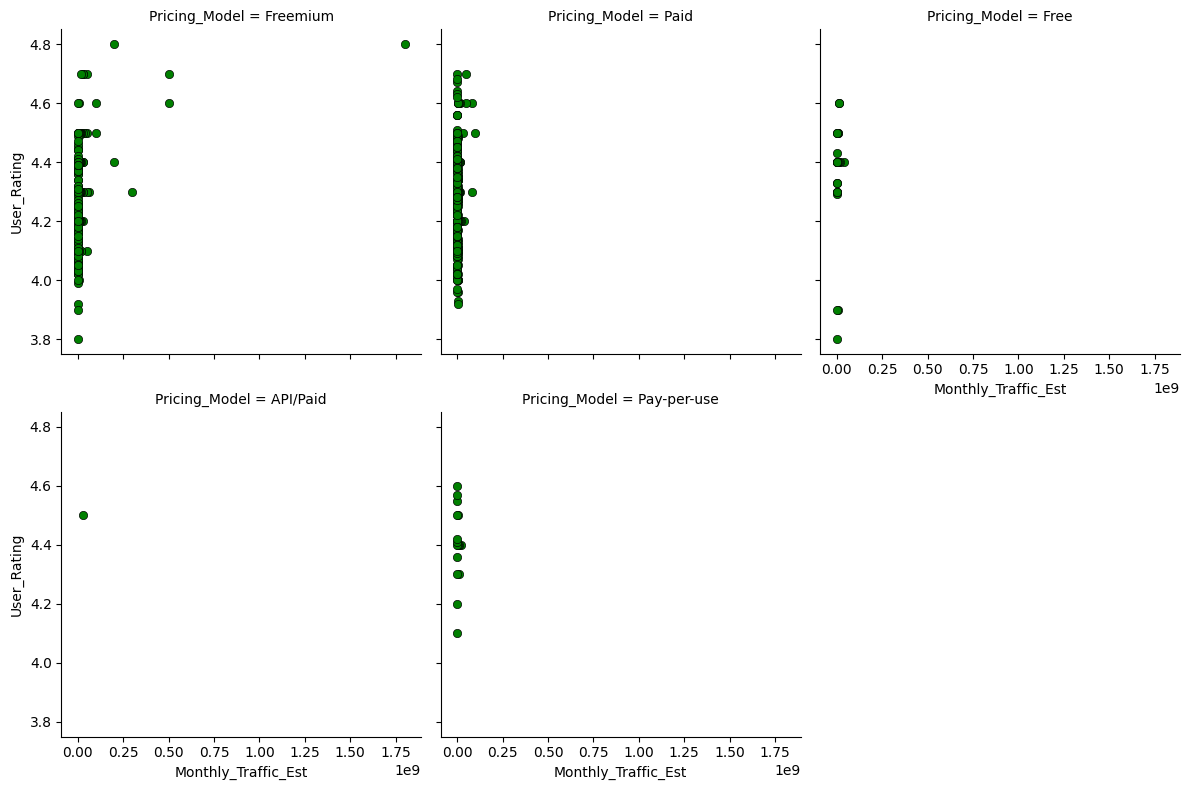

In [27]:
# 4. FACET GRID BY PRICING MODEL

g = sns.FacetGrid(
    data,
    col='Pricing_Model',
    col_wrap=3,
    height=4,
)

g.map(
    sns.scatterplot,
    'Monthly_Traffic_Est',
    'User_Rating',
    color='green',  # set point color here
    edgecolor='black'
)

plt.show()

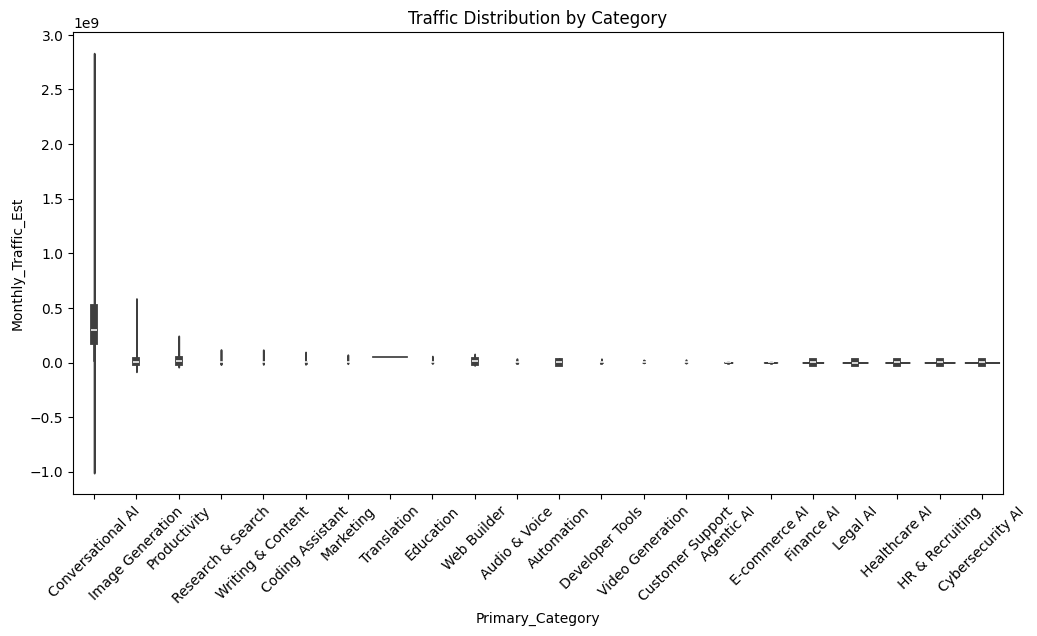

In [28]:
# 5. CATEGORY-WISE TRAFFIC DISTRIBUTION (VIOLIN PLOT)

plt.figure(figsize=(12,6))

sns.violinplot(
    x='Primary_Category',
    y='Monthly_Traffic_Est',
    data=data
)

plt.xticks(rotation=45)
plt.title("Traffic Distribution by Category")

plt.show()

C:\Users\MONOHER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\categorical.py:3399: UserWarning: 6.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\MONOHER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\categorical.py:3399: UserWarning: 15.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\MONOHER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\categorical.py:3399: UserWarning: 22.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


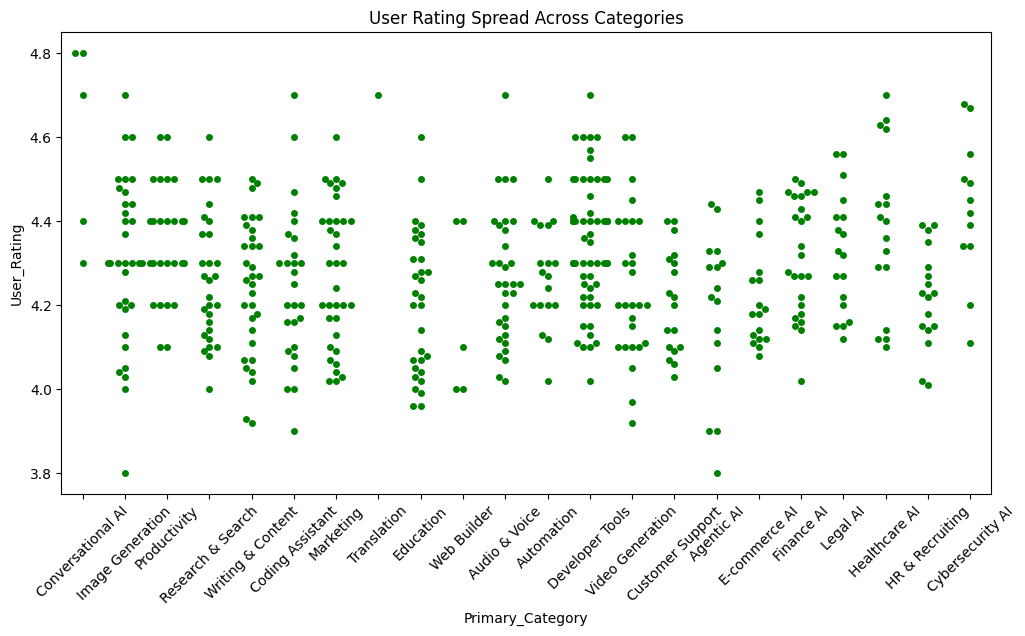

In [31]:
# 6. CATEGORY VS RATING (SWARM PLOT)

plt.figure(figsize=(12,6))

sns.swarmplot(
    x='Primary_Category',
    y='User_Rating',
    data=data,color='green',edgecolor='black'
)

plt.xticks(rotation=45)
plt.title("User Rating Spread Across Categories")

plt.show()

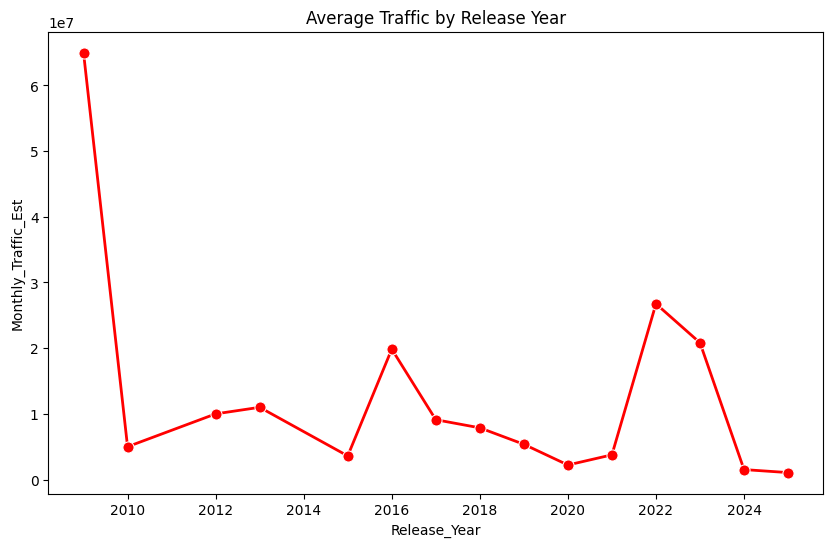

In [37]:
# 7. RELEASE YEAR IMPACT ON TRAFFIC (LINE + POINT PLOT)

year_avg_traffic = data.groupby('Release_Year')['Monthly_Traffic_Est'].mean().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    x='Release_Year',
    y='Monthly_Traffic_Est',
    data=year_avg_traffic,color='red',marker='o',markersize=8,linewidth=2
)

sns.scatterplot(
    x='Release_Year',
    y='Monthly_Traffic_Est',
    data=year_avg_traffic,color='black',edgecolor='black'
)

plt.title("Average Traffic by Release Year")

plt.show()